In [1]:
import pandas as pd
import numpy as np

In [2]:
df_agriculture = pd.read_csv(r"C:\Users\thyde\Documents\OMDS Resources\DX 799 O1 Data Science Capstone\climate_change_impact_on_agriculture_2024 - climate_change_impact_on_agriculture_2024.csv")
df_usa_agr = df_agriculture[df_agriculture["Country"] == "USA"]
df_usa_agr_clean = df_usa_agr.drop(['Year','Soil Health Index','Irrigation Access %', 'Total Precipitation (mm)'], axis=1)
df_usa_agr_numeric = df_usa_agr_clean.select_dtypes(include="number")
df_usa_agr_numeric.head()

,Average Temperature (C),CO2 Emissions (MT),Crop Yield (MT per HA),Extreme Weather Events,Pesticide Use (KG per HA),Fertilizer Use (KG per HA),Economic Impact (Million USD)
8968,17.19,10.73,2.180,5,26.06,71.56,353.16
8969,14.70,11.45,2.500,9,19.48,46.13,1126.27
8970,12.03,3.86,2.450,8,13.10,2.56,1026.35
8971,12.18,19.10,1.872,8,43.15,22.46,925.79
8972,30.62,29.28,3.249,9,5.80,49.85,509.77


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Create binary target
y = (df_usa_agr_numeric["Crop Yield (MT per HA)"] > 
     df_usa_agr_numeric["Crop Yield (MT per HA)"].median()).astype(int)

# Features
X = df_usa_agr_numeric.drop(columns=["Crop Yield (MT per HA)"])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Logistic regression pipeline
log_reg_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000))
])

# Fit model
log_reg_model.fit(X_train, y_train)

# Predict
y_pred = log_reg_model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7584541062801933

Confusion Matrix:
[[82 22]
 [28 75]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.79      0.77       104
           1       0.77      0.73      0.75       103

    accuracy                           0.76       207
   macro avg       0.76      0.76      0.76       207
weighted avg       0.76      0.76      0.76       207



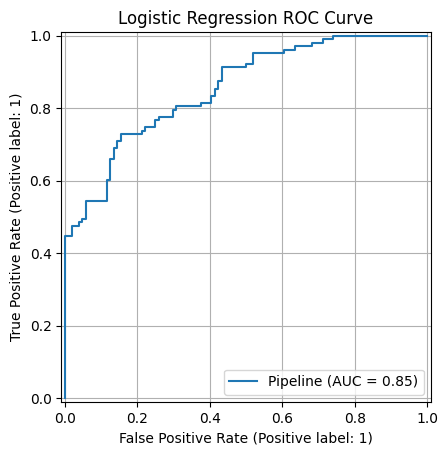

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(log_reg_model, X_test, y_test)
plt.title("Agricultural Logistic Regression ROC Curve")
plt.grid(True)
plt.show()

In [5]:
df_CO2 = pd.read_csv(r"C:\Users\thyde\Documents\OMDS Resources\DX 799 O1 Data Science Capstone\owid-co2-data.csv")
numeric_df_CO2 = df_CO2.select_dtypes(include='number') 
nona_numeric_df_CO2 = numeric_df_CO2.dropna()
clean_numeric_dfCO2 = nona_numeric_df_CO2[['gdp','co2_growth_prct','co2_per_capita','co2_per_gdp','temperature_change_from_co2']].copy()
clean_numeric_dfCO2.head()

,gdp,co2_growth_prct,co2_per_capita,co2_per_gdp,temperature_change_from_co2
3644,4.641366e+11,8.263,16.236,0.599,0.008
3645,4.613021e+11,0.495,16.103,0.606,0.008
3646,4.786337e+11,1.788,16.208,0.594,0.008
3647,5.015248e+11,1.528,16.294,0.576,0.008
3648,5.279932e+11,1.674,16.405,0.556,0.008


In [6]:
y = (clean_numeric_dfCO2["temperature_change_from_co2"] > 
     clean_numeric_dfCO2["temperature_change_from_co2"].median()).astype(int)
X = clean_numeric_dfCO2.drop(columns=["temperature_change_from_co2"])
# Features


# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Logistic regression pipeline
log_reg_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000))
])

# Fit model
log_reg_model.fit(X_train, y_train)

# Predict
y_pred = log_reg_model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8333333333333334

Confusion Matrix:
[[134   9]
 [ 38 101]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.94      0.85       143
           1       0.92      0.73      0.81       139

    accuracy                           0.83       282
   macro avg       0.85      0.83      0.83       282
weighted avg       0.85      0.83      0.83       282



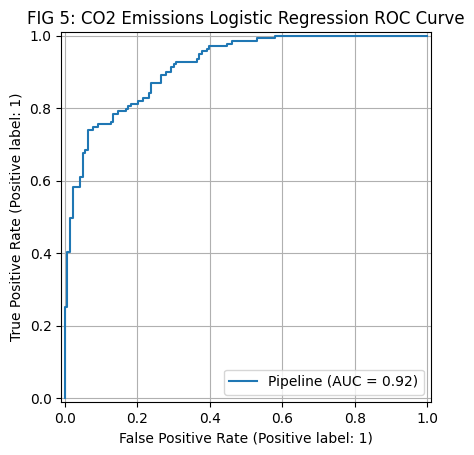

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(log_reg_model, X_test, y_test)
plt.title("FIG 5: CO2 Emissions Logistic Regression ROC Curve")
plt.grid(True)
plt.show()